In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_pickle('../data/processed/emails_with_anomalies.pkl')
topic_dist = np.load('../data/features/topic_distributions.npy')
print(f"Loaded {len(df):,} emails")

Loaded 458,386 emails


/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_77329/4260266688.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_topics = df.groupby([df['datetime'].dt.to_period('M'), 'dominant_topic']).size()


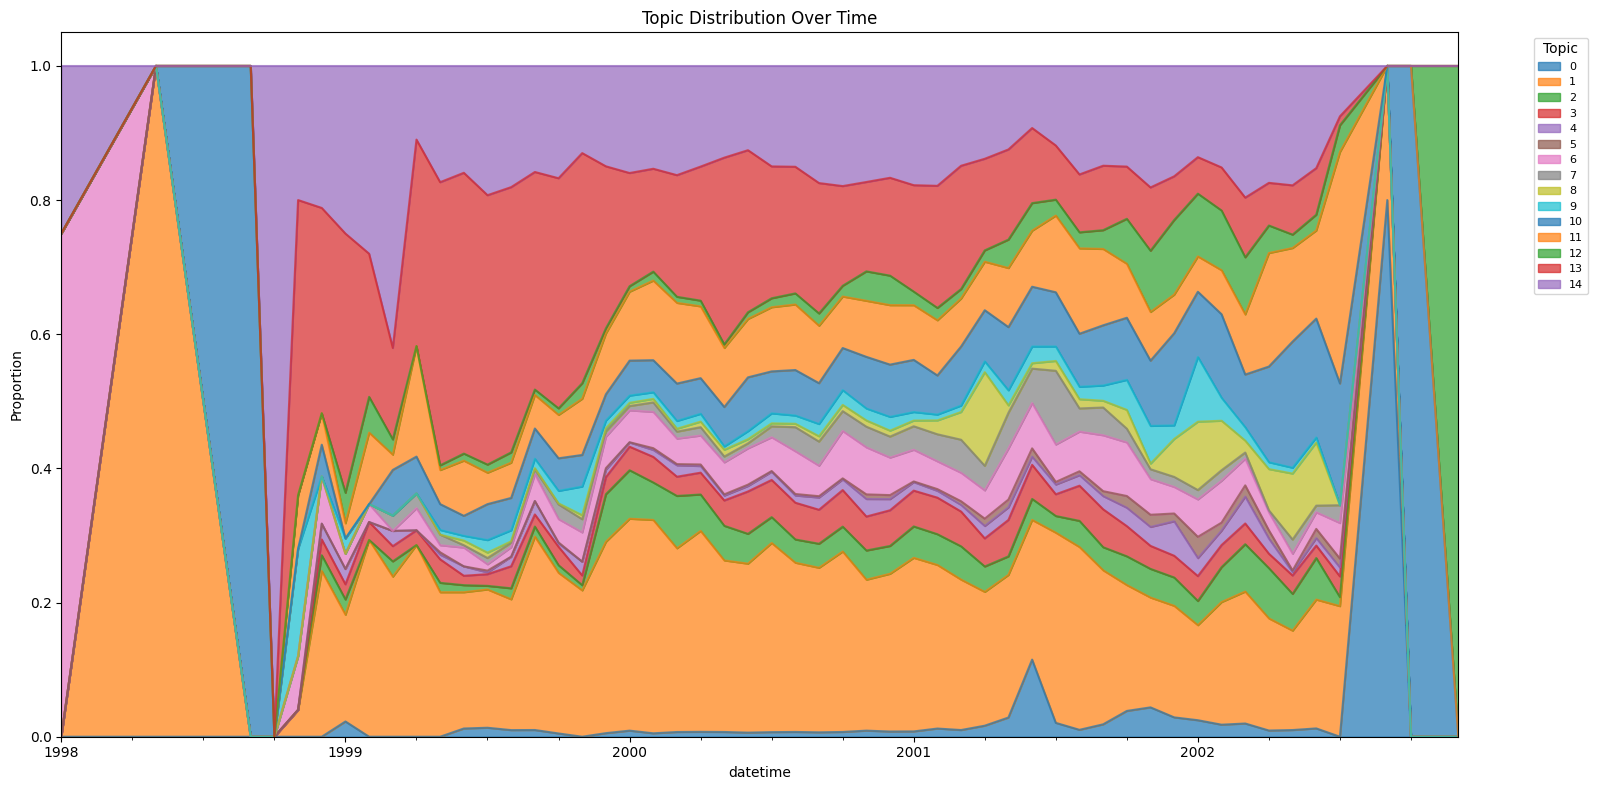

In [2]:
# Monthly topic distribution
monthly_topics = df.groupby([df['datetime'].dt.to_period('M'), 'dominant_topic']).size()
monthly_topics = monthly_topics.unstack(fill_value=0)
monthly_topics_pct = monthly_topics.div(monthly_topics.sum(axis=1), axis=0)

# Stacked area chart of topic evolution
fig, ax = plt.subplots(figsize=(16, 8))
monthly_topics_pct.plot.area(ax=ax, alpha=0.7)
ax.set_title('Topic Distribution Over Time')
ax.set_ylabel('Proportion')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title='Topic')

# Mark key Enron events
key_events = {
    '2001-08': 'Skilling resigns',
    '2001-10': 'SEC investigation',
    '2001-12': 'Bankruptcy'
}
for date, event in key_events.items():
    ax.axvline(x=monthly_topics_pct.index.get_loc(date), color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../results/figures/topic_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_77329/1719186760.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_anomaly = df.groupby(df['datetime'].dt.to_period('M')).agg(


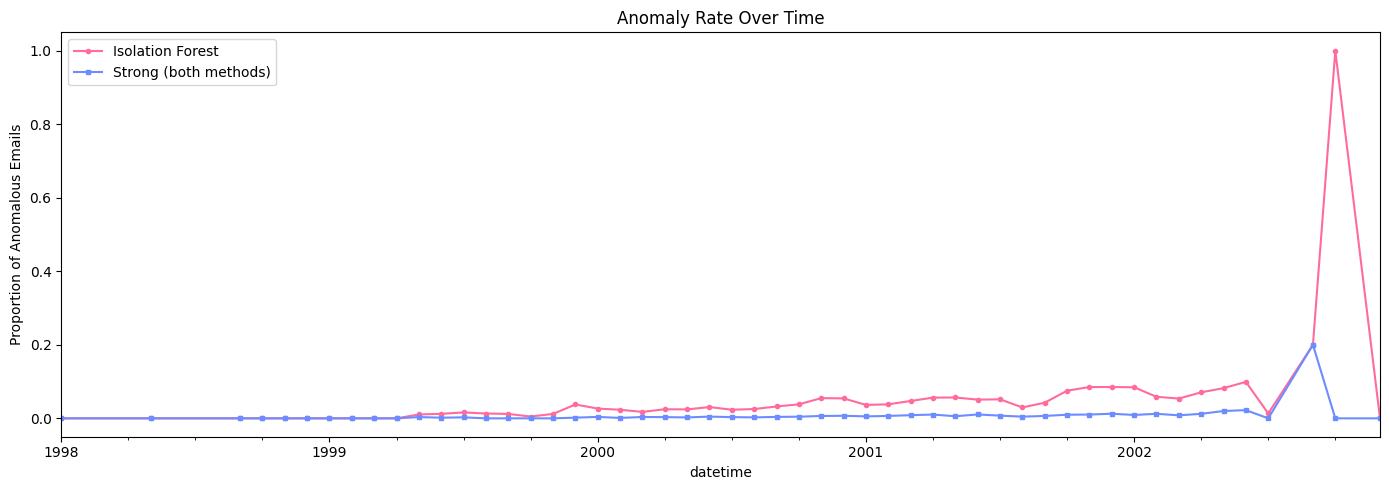

In [3]:
# Monthly anomaly rates
monthly_anomaly = df.groupby(df['datetime'].dt.to_period('M')).agg(
    total=('anomaly_iso', 'count'),
    anomalies=('anomaly_iso', lambda x: (x == -1).sum()),
    strong=('strong_anomaly', 'sum')
)
monthly_anomaly['rate'] = monthly_anomaly['anomalies'] / monthly_anomaly['total']
monthly_anomaly['strong_rate'] = monthly_anomaly['strong'] / monthly_anomaly['total']

fig, ax = plt.subplots(figsize=(14, 5))
monthly_anomaly['rate'].plot(ax=ax, marker='o', color='#ff6b9d', markersize=3, label='Isolation Forest')
monthly_anomaly['strong_rate'].plot(ax=ax, marker='s', color='#6c8cff', markersize=3, label='Strong (both methods)')
ax.set_title('Anomaly Rate Over Time')
ax.set_ylabel('Proportion of Anomalous Emails')
ax.legend()

# Mark key events
for date in ['2001-08', '2001-10', '2001-12']:
    try:
        ax.axvline(x=monthly_anomaly.index.get_loc(date), color='gray', linestyle='--', alpha=0.5)
    except:
        pass

plt.tight_layout()
plt.savefig('../results/figures/anomaly_rate_timeline.png', dpi=150)
plt.show()

/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_77329/648466069.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = user_data.groupby(user_data['datetime'].dt.to_period('M'))['avg_word_length'].mean()
/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_77329/648466069.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = user_data.groupby(user_data['datetime'].dt.to_period('M'))['avg_word_length'].mean()
/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_77329/648466069.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = user_data.groupby(user_data['datetime'].dt.to_period('M'))['avg_word_length'].mean()
/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_77329/648466069.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = u

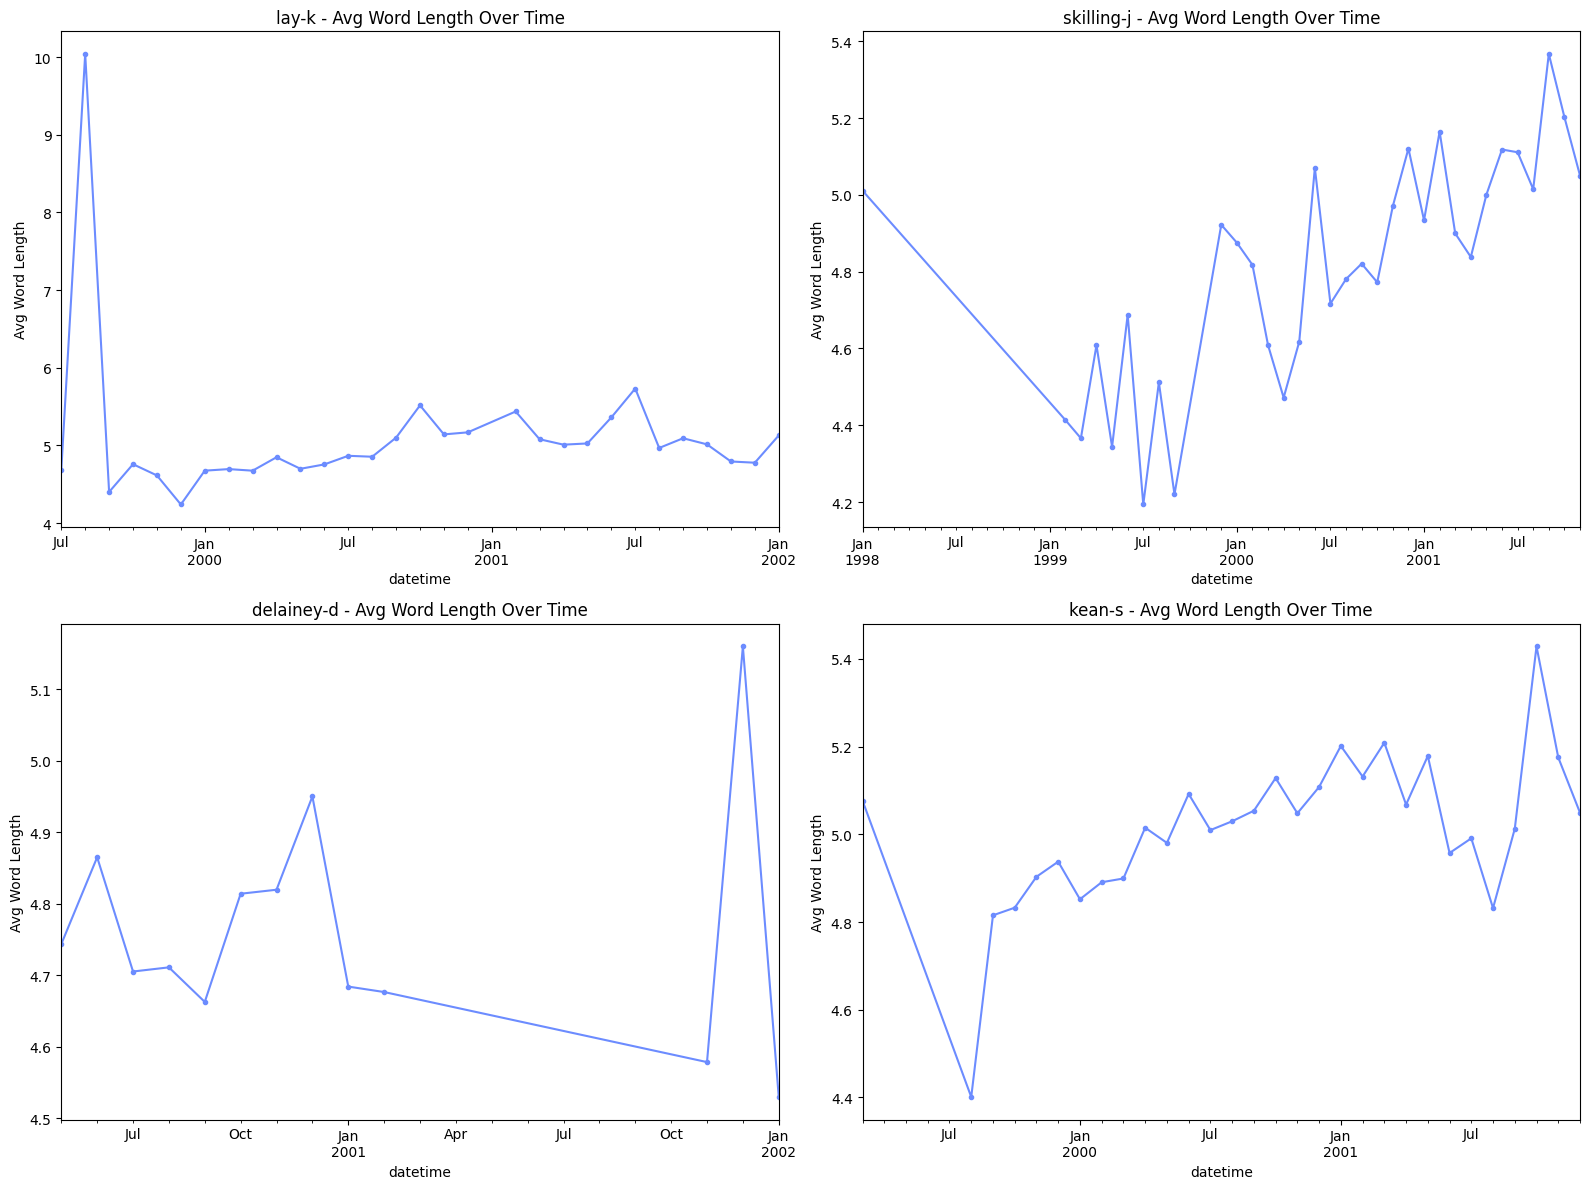

In [4]:
style_df = pd.read_pickle('../data/features/stylistic_features.pkl')

key_users = ['lay-k', 'skilling-j', 'delainey-d', 'kean-s']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, user in zip(axes.flat, key_users):
    user_mask = df['user'] == user
    user_data = df[user_mask].copy()
    user_style = style_df[user_mask].copy()
    user_data['avg_word_length'] = user_style['avg_word_length'].values
    
    monthly = user_data.groupby(user_data['datetime'].dt.to_period('M'))['avg_word_length'].mean()
    monthly.plot(ax=ax, marker='o', markersize=3, color='#6c8cff')
    ax.set_title(f'{user} - Avg Word Length Over Time')
    ax.set_ylabel('Avg Word Length')
    
    # Mark key events
    for date in ['2001-08', '2001-10', '2001-12']:
        try:
            ax.axvline(x=monthly.index.get_loc(date), color='red', linestyle='--', alpha=0.5)
        except:
            pass

plt.tight_layout()
plt.savefig('../results/figures/key_users_style_change.png', dpi=150)
plt.show()

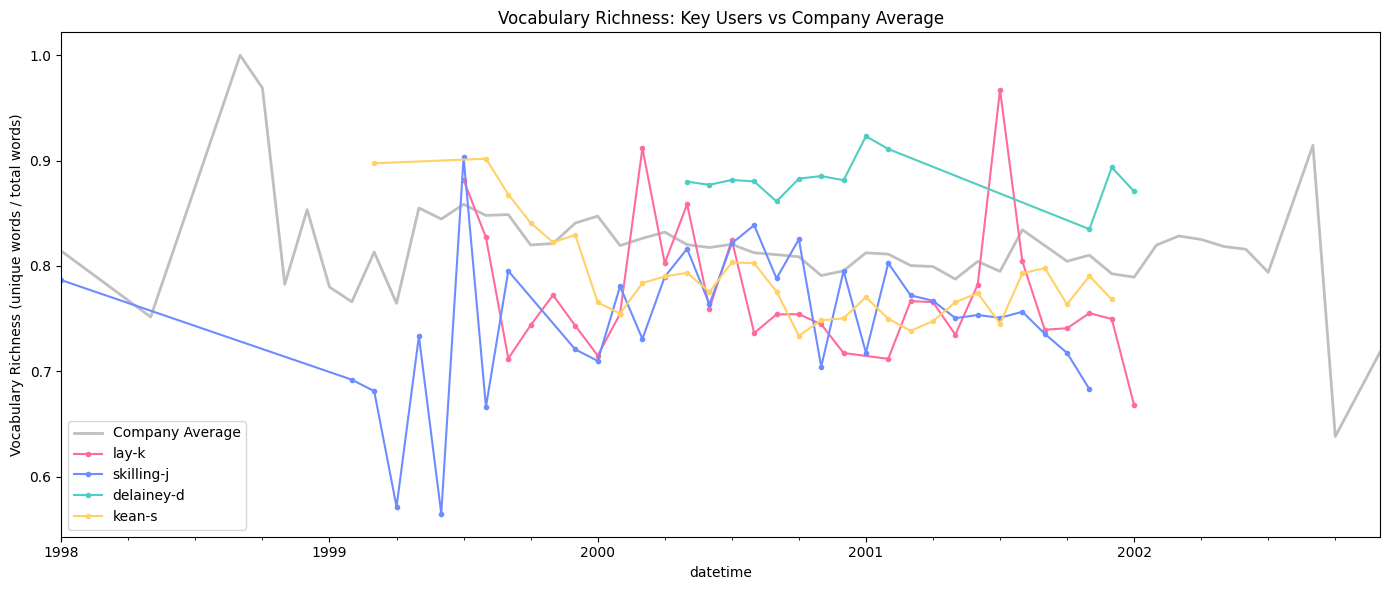

In [5]:
# Compare key users vs company average
style_df_copy = style_df.copy()
style_df_copy['user'] = df['user'].values
style_df_copy['datetime'] = df['datetime'].values

# Overall company average per month
overall_monthly = style_df_copy.groupby(pd.to_datetime(style_df_copy['datetime']).dt.to_period('M'))['vocab_richness'].mean()

fig, ax = plt.subplots(figsize=(14, 6))
overall_monthly.plot(ax=ax, color='gray', linewidth=2, label='Company Average', alpha=0.5)

colors = ['#ff6b9d', '#6c8cff', '#4ecdc4', '#ffd166']
for user, color in zip(key_users, colors):
    user_mask = style_df_copy['user'] == user
    user_monthly = style_df_copy[user_mask].groupby(
        pd.to_datetime(style_df_copy[user_mask]['datetime']).dt.to_period('M')
    )['vocab_richness'].mean()
    user_monthly.plot(ax=ax, color=color, marker='o', markersize=3, label=user)

ax.set_title('Vocabulary Richness: Key Users vs Company Average')
ax.set_ylabel('Vocabulary Richness (unique words / total words)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/vocab_richness_comparison.png', dpi=150)
plt.show()

In [6]:
df.to_pickle('../data/processed/emails_with_anomalies.pkl')
print("Saved temporal analysis data")

Saved temporal analysis data
